ambiente anconda YouTube

no terminal do linux 

conda env list

conda activate YouTube

# Projeto 1: Classificação binária brest cancer

## Etapa 1: Importação das bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
import torch
torch.__version__
#!pip install torch==1.4.0

'2.8.0+cu128'

In [3]:
import torch.nn as nn # nn neural network -> rede neural
# atalho do pacote

## Etapa 2: Base de dados

In [4]:
# semente gerado aleatória:
# sempre gera os mesmos números alatórios
# reprodutividades dos elementos +> a cada vez que rodamos teremos os mesmos valores
np.random.seed(123)
# definição das redes neurais, para inserir os pesos com os mesmos resultados. 
torch.manual_seed(123)

In [5]:
previsores = pd.read_csv('entradas_breast.csv') # variáveis que indicam as características, para ajudar a prever.
classe = pd.read_csv('saidas_breast.csv') # classe 0 e 1, para indicar se tem ou não Câncer

In [6]:
previsores.shape # 

(569, 30)

In [7]:
print(f'{previsores.shape[0]} pessoas cadastradas.')

569 pessoas cadastradas.


In [8]:
print(f'{previsores.shape[1]} características ou dados dos tumores.')

30 características ou dados dos tumores.


In [9]:
previsores.head(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,186.0000,275.0000,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,243.0000,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,173.00000
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,198.0000,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,205.0000,0.4000,0.1625,0.2364,0.07678


In [10]:
previsores.tail(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
564,21.56,22.39,142.00,1479.0,111.00000,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,141.00000,0.21130,0.4107,0.2216,206.0000,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,144.00000,0.09791,0.1752,0.05533,...,23.69,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,159.0000,0.05648,...,18.98,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,277.00000,0.35140,152.00000,0.2397,0.07016,...,25.74,39.42,184.60,1821.0,165.00000,0.86810,0.9387,265.0000,0.4087,124.00000
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9456.00,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [11]:
# detalhes do tumor
previsores.columns

Index([' radius_mean', ' texture_mean', ' perimeter_mean', ' area_mean',
       ' smoothness_mean', ' compactness_mean', ' concavity_mean',
       'concave_points_mean', ' symmetry_mean', ' fractal_dimension_mean',
       ' radius_se', ' texture_se', ' perimeter_se', ' area_se',
       ' smoothness_se', ' compactness_se', ' concavity_se',
       ' concave_points_se', ' symmetry_se', ' fractal_dimension_se',
       ' radius_worst', ' texture_worst', ' perimeter_worst', ' area_worst',
       ' smoothness_worst', ' compactness_worst', ' concavity_worst',
       ' concave_points_worst', ' symmetry_worst', ' fractal_dimension_worst'],
      dtype='object')

In [12]:
classe.head()

,0
0,0
1,0
2,0
3,0
4,0


0 tumor benigno

1 tumor maligno

In [13]:
np.unique(classe) # contagem

array([0, 1])

## Gráfico de contagens

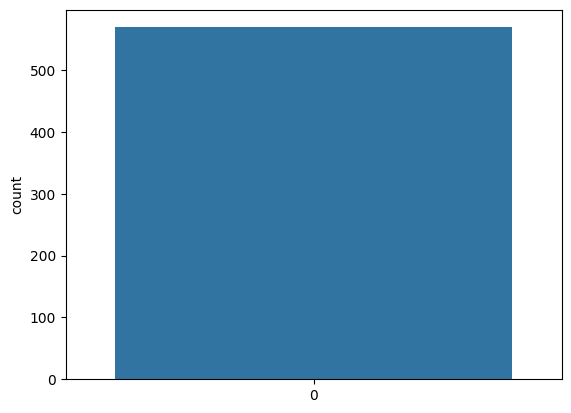

In [14]:
sns.countplot(classe);

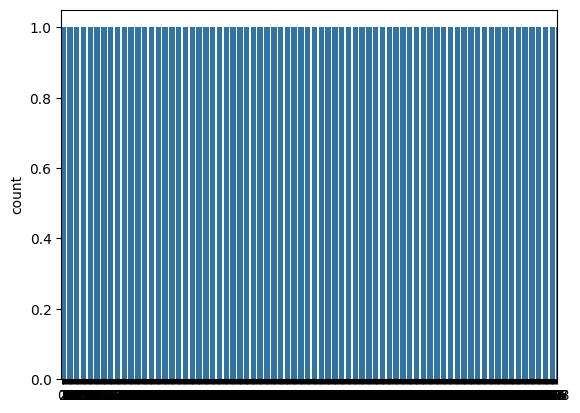

In [15]:
sns.countplot(classe['0']);

In [16]:
classe.columns

Index(['0'], dtype='object')

In [17]:
np.unique(classe, return_counts=True)

(array([0, 1]), array([212, 357]))

In [18]:
valores_unicos, contagens = np.unique(classe, return_counts=True)
df_count = pd.DataFrame({
    'classe': valores_unicos,
    'contagem': contagens #
})
df_count

,classe,contagem
0,0,212
1,1,357


In [19]:
import matplotlib.pyplot as plt

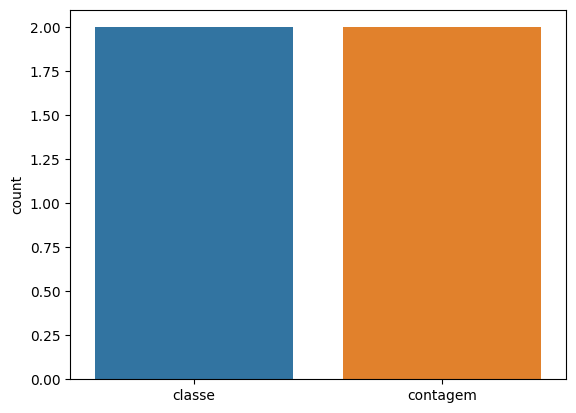

In [20]:
sns.countplot(df_count);

In [21]:
classe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


In [22]:
df_classe= classe.rename(columns={'0':'Classes'})

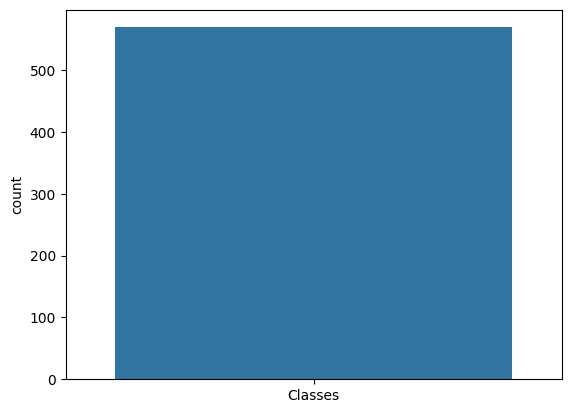

In [23]:
sns.countplot(df_classe);

/tmp/ipykernel_5406/706469331.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Classes', data=df_classe,palette='viridis')


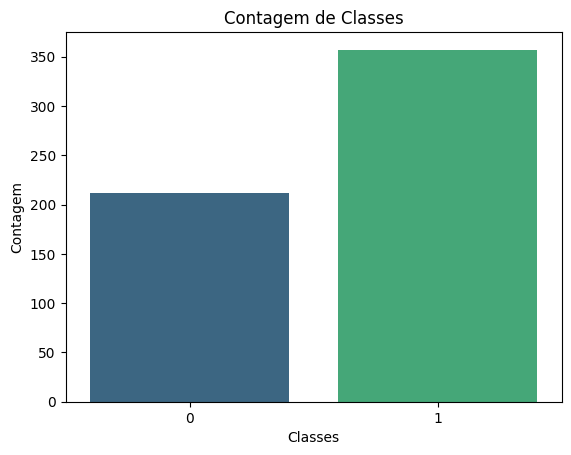

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plote a contagem usando a coluna 'Classes'
sns.countplot(x='Classes', data=df_classe,palette='viridis')


plt.title('Contagem de Classes')
plt.xlabel('Classes')
plt.ylabel('Contagem')

# Exiba o gráfico
plt.show()

# dividir os dados de treinamento e teste 

In [25]:
previsores_treinamento, previsores_teste, classe_treinamento, classe_teste = train_test_split(previsores,
                                                                                              classe,
                                                                                              test_size = 0.25)

# parâmetro do teste, será de 25%. 
# resta os 75% para fazer o treinamento. 

In [26]:
previsores_treinamento.shape

(426, 30)

In [27]:
classe_treinamento.shape

(426, 1)

In [28]:
previsores_teste.shape

(143, 30)

In [29]:
classe_teste.shape

(143, 1)

## Etapa 3: Transformação dos dados para tensores


Para usarmos o pytorch

In [30]:
type(previsores_treinamento)

pandas.core.frame.DataFrame

## ==> # transformaremos os dados para o numpy e depois para o torch

In [31]:
type(np.array(previsores_treinamento))

numpy.ndarray

In [32]:
#  torch.tensor:
# redefinir as variáveis
# tensor, parecidos com o array, com característicsa extras para permitir o seu uso em aplicações de machine learning. 
# E para os processamentos em GPUS

# isso otimiza melhor para aplicações mais complexas que exigem um alto grau de processamento. 

# para transformar em tensor, precisa antes ser array.

In [33]:
previsores_treinamento = torch.tensor(np.array(previsores_treinamento), dtype=torch.float)
classe_treinamento = torch.tensor(np.array(classe_treinamento), dtype = torch.float)

In [34]:
type(previsores_treinamento)

torch.Tensor

In [35]:
type(classe_treinamento)

torch.Tensor

## dados preparados para trabalharmos com o pytorch

In [36]:
# dataset para passar como parâmetro

In [37]:
# duas variáveis separadas (previsores e classes), e transformar em uma única variável. 

In [38]:
dataset = torch.utils.data.TensorDataset(previsores_treinamento, classe_treinamento)

# dataset será a variável para passar para o nosso treinamento. 

In [39]:
type(dataset) # classe -> torch.utils.data.dataset.TensorDataset


torch.utils.data.dataset.TensorDataset

In [40]:
# a idea é misturar os dados
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)

#### pytorch faz o treinamento das mini batch, e fornecemos um dataloader, conforme as nossas classes que definimos. 
#### para que façam as interações e repetições. Conceito de batch_size que passa uma quantidade determinada de registros para fazer o ajuste dos pesos, por exemplo:
#### colocando batch_size = 10, passa 10 registros, um batch com 10 registros - pytorch calcula o erro para esses 10 registros e depois ele faz as atualizações dos pesos.
#### depois pegamos mais 10 registros e passamos para ele fazer os ajustes dos pesos, e mais 10 batch registros para fazer atualizações do pesos.
#### Dataloder é uma classe responsável para fornecer o número certo de dados de acordo com esse tamanho de batch.   

In [41]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)


- Batch: essa classe garante que o treinamento de ajustes dos pesos sejam feitos de 10 em 10 registros, para cada uma das repetições. O que faz é manter um histórico dos dados que foram fornecidos, de forma a não repetir os mesmos daos dentro da mesma época. Por exemplo, ele acaba utilizando os mesmos dados para fazer o ajuste dos pesos. 
Então essa classe também vai garantir que le sempre utilizem registros diferentes 


- e o primeiro parâmetro é o dataset (tensor dataset), tantos previsores e classes (concatenados)

1) torch.utils.data.DataLoader =>  classe principal que cria o objeto de carregador de dados. Age como um iterador que fornece dados de forma eficiente.

2) dataset: É a sua coleção completa de dados (entradas e rótulos). O DataLoader irá usar este objeto para extrair as amostras.

3) batch_size=10: Este parâmetro define o tamanho dos "mini-lotes" de dados. Em vez de alimentar o modelo com uma única amostra de cada vez, o DataLoader agrupa 10 amostras juntas. Isso é crucial para o treinamento, pois acelera o processo e permite um uso mais eficiente da memória, especialmente com GPUs.

4) shuffle=True: Este parâmetro garante que, no início de cada "época" de treinamento (ou seja, cada vez que o modelo vê o conjunto de dados completo), os dados serão embaralhados aleatoriamente. Isso é importante para evitar que o modelo aprenda a ordem dos dados, o que poderia prejudicar seu desempenho e sua capacidade de generalização.

## Etapa 4: Construção do modelo

In [67]:
# 30 -> atributos previsores, ou seja 30 colunas na tabela previsores_treinamento

# 2 camadas de ocultas, cada uma com 16 neurônios

# 1 camada de saída 

In [43]:
# 30 -> 16 -> 16 -> 1
# (entradas + saida) / 2 = (30 + 1) / 2 = 16  => cálculo da quantidade de neurônios nas camadas ocultas

# Classificação binária => Nós temos as respostas de 0 e 1.

# 1 câncer perigoso ou maligno, e 0 sem o câncer benigno.


classificador = nn.Sequential(
    # Camada Linear => densa, de entrada, que é onde os neurônios da camada de entrada ligam se a todos os neurônios dessa camada oculta.
    # camada dense, entrada de 30 neurônios ou colunas dos previsores (número de atributos, ligados a saída para a camada oculta 16
    nn.Linear(in_features=30, out_features=16), # Camada totalmente conectada (30 entradas → 16 neurônios)
    # Função de ativação ReLU
    # aplicada nos 16 neurônios o ReLU
    nn.ReLU(), # Função de ativação ReLU aplicada nos 16 neurônios
    # aplicar entre as duas camadas ocultas de 16 neurônios cada
    nn.Linear(16, 16), # Outra camada densa (16 entradas → 16 saídas)
    # função ReLU aplicadas na segunda camada oculta , com 16 neurônios.
    nn.ReLU(), # Ativação ReLU novamente
    # camada linear densa da segunda camada oculta para a camada de saída. 
    nn.Linear(16, 1),    # Camada final (16 entradas → 1 saída)
    # função de ativação será aplicada será a Sigmoid, será a probabilidade. 
    nn.Sigmoid()   # Função de ativação Sigmoid (output entre 0 e 1)
)

In [44]:
classificador

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

nn pacote do neurônio, da rede reural do pytorch.

sequential, sequência de camadas. 

https://docs.pytorch.org/docs/stable/nn.html

https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html

https://github.com/FrancescoSaverioZuppichini/Pytorch-how-and-when-to-use-Module-Sequential-ModuleList-and-ModuleDict 

Camada Linear => densa, de entrada, que é onde os neurônios da camada de entrada ligam se a todos os neurônios dessa camada oculta. 

ver a estrutura da rede

bias, neurônios adicionais.

In [45]:
classificador.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)>

### Funções de ativação mais usadas

#### - Sigmoid (nn.Sigmoid)

Saída entre 0 e 1.

Boa para classificação binária.

Problema: gradiente pode "sumir" em valores extremos.

#### -  Tanh (nn.Tanh)

Saída entre -1 e 1.

Similar à Sigmoid, mas centrada no zero.

#### -  ReLU (nn.ReLU)

Retorna 0 se x < 0, e x se x ≥ 0.

Muito usada em redes profundas porque evita saturação.

#### -  Leaky ReLU (nn.LeakyReLU)

Versão melhorada da ReLU (deixa passar um valor pequeno quando x < 0).

#### - Softmax (nn.Softmax)

Transforma valores em probabilidades que somam 1.

Usada na saída de classificação multiclasse.

In [46]:
# criar a função de erro.

In [47]:
criterion = nn.BCELoss() #Binary cross-entropy (BCE)

Binary cross-entropy (BCE), also known as log loss, is a loss function in machine learning for binary classification problems that quantifies the difference between the actual binary labels (0 or 1) and the predicted probabilities of the positive class. It measures how well the model's predicted probabilities align with the true labels, with lower BCE values indicating better performance. The function penalizes confident but incorrect predictions heavily, and it's crucial for training models like logistic regression and neural networks to minimize prediction error and improve accuracy.  

- Binary cross-entropy: comparação com as previsões e os registros reais, ajustes dos pesos, para saber do gradiente, se ele vai aumentar ou diminuir. 

In [48]:
# otimizador
optimizer = torch.optim.Adam(classificador.parameters(), lr=0.001, weight_decay=0.0001)

In [49]:
# otimizador, adam com resultados interessantes. 
# passamos os parâmetros , lr learing rate -> que é 0,001, weight_decay x de epocas, diminui o valor do lr, para se aproximar do gradiente. 

# lr learing rate será multiplicado pelo weight_decay, para chegar no mínimo global. 

Se a saída for previsão de vendas (ou seja, um número real contínuo → problema de regressão), então:

Não usamos Sigmoid, porque ela limita a saída entre 0 e 1 (inadequado para valores grandes de vendas).

Não usamos Softmax, porque é para classificação multiclasse.

O mais comum é não colocar nenhuma função de ativação na saída (ou seja, só nn.Linear(..., 1) na última camada).
          
Isso deixa a rede livre para prever qualquer valor real (positivo ou negativo).

nn.Linear(16, 1)   # saída contínua



https://www.youtube.com/watch?v=m2CLbHZHLB4

## Etapa 5: Treinamento do modelo

In [50]:
# fit passa os dados e faz o treinamento automaticamente
# fazer um for e um loop manual para fazer o treinamento. 
# rodar por 100 vezes as atualizações dos pesos
# lembrando que temos 426 registros ou linhas nos nossos bancos de dados. 
# passando de 10 em 10 conforme o batch_size, que calcula o erro para esses 10 registros e depois ele faz as atualizações os pesos
# 426/10 = 42,6 vezes ajustes dos pesos dentro de cada época, epoch
426/10

42.6

In [51]:

# no for vai executar os 43 ajustes de pesos dentro de cada um desses for e nós executamos 100 vezes. 
# em cada uma das épocas nós vamos passar pelos 426 registros, porém esses registros estarão dividiso de 10 e 10. 
# na primeira época (epoch) ele pega 10 registros e cálcula o erro => então ajusta os pesos, e depois mais 10 e mais dez. Até terminar esses 42,6 ou 46 batch
# Vamos inicializar uma variável para acumular o erro. 

# os dados são preparados com a separação do batch_size
# train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)
# 426/10=43 batchs, em cada batch são 10 em 10

i=1
for epoch in range(100):
  running_loss = 0. # para termos o inflow
  i +=1 
  for data in train_loader:
    inputs, labels = data  # inputs = entradas previsores, labels = respostas reais
    print(inputs) # atributos previsores, que são 10 reguistros
    print('-----')
    print(labels) # classes, que são dividiso em 10
    if i > 1:
        break

tensor([[1.1080e+01, 1.8830e+01, 7.3300e+01, 3.6160e+02, 1.2160e-01, 2.1540e-01,
         1.6890e-01, 6.3670e-02, 2.1960e-01, 7.9500e-02, 2.1140e-01, 1.0270e+03,
         1.7190e+03, 1.3990e+01, 7.4050e-03, 4.5490e-02, 4.5880e-02, 1.3390e-02,
         1.7380e-02, 4.4350e-03, 1.3240e+01, 3.2820e+01, 9.1760e+01, 5.0810e+02,
         2.1840e-01, 9.3790e-01, 8.4020e-01, 2.5240e-01, 4.1540e-01, 1.4030e-01],
        [1.9400e+01, 2.3500e+01, 1.2910e+02, 1.1550e+03, 1.0270e-01, 1.5580e-01,
         2.0490e-01, 8.8860e-02, 1.9780e-01, 6.0000e-02, 5.2430e-01, 1.8020e+03,
         4.0370e+03, 6.0410e+01, 1.0610e-02, 3.2520e-02, 3.9150e-02, 1.5590e-02,
         2.1860e-02, 3.9490e-03, 2.1650e+01, 3.0530e+01, 1.4490e+02, 1.4170e+03,
         1.4630e-01, 2.9680e-01, 3.4580e-01, 1.5640e-01, 2.9200e+02, 7.6140e-02],
        [1.1260e+01, 1.9960e+01, 7.3720e+01, 3.9410e+02, 8.0200e-02, 1.1810e-01,
         9.2740e-02, 5.5880e-02, 2.5950e-01, 6.2330e-02, 4.8660e-01, 1.9050e+03,
         2.8770e+03, 3.468

#  loss.backward()


##### registros cálcula a multiplicação e a função de ativação e a resposta com a ativação. 

<b>peso n+1 = (peson * momento) + (entrada * delta * taxa de aprendizagem)</b>

que cálcula e chega ao final e recalcula ou atualiza os pesos. Temos 2 processos.

o foward passa os registros e faz os cálculos, mas no final chega a resposta e tem o erro (o loss). Precisamos voltar, como backward e atualizar os pesos 


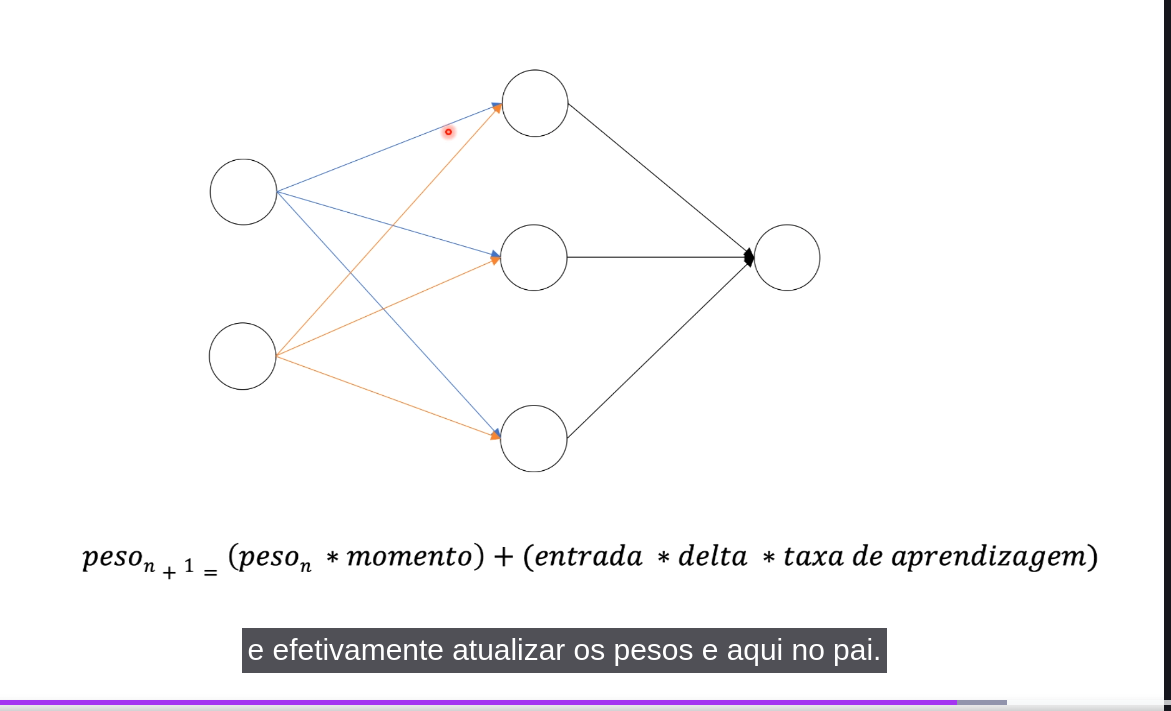


In [52]:


# fit passa os dados e faz o treinamento automaticamente
# fazer um for e um loop manual para fazer o treinamento. 
# rodar por 100 vezes as atualizações dos pesos
# lembrando que temos 426 registros ou linhas nos nossos bancos de dados. 
# passando de 10 em 10 conforme o batch_size, que calcula o erro para esses 10 registros e depois ele faz as atualizações os pesos
# 426/10 = 42,6 vezes ajustes dos pesos dentro de cada época, epoch

# no for vai executar os 43 ajustes de pesos dentro de cada um desses for e nós executamos 100 vezes.

# em cada uma das épocas nós vamos passar pelos 426 registros, porém esses registros estarão dividiso de 10 e 10. 
# na primeira época (epoch) ele pega 10 registros e cálcula o erro => então ajusta os pesos, e depois mais 10 e mais dez. Até terminar esses 42,6 ou 46 batch

# Vamos inicializar uma variável para acumular o erro. 



# os dados são preparados com a separação do batch_size
# train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)
# 426/10=43 batchs, em cada batch são 10 em 10



i = 0
for epoch in range(100):
  running_loss = 0. # para termos o inflow
  i +=1
  for data in train_loader:
    inputs, labels = data  # inputs = entradas previsores, labels = respostas reais
    print(inputs) # atributos previsores, que são 10 reguistros
    print('-----')
    print(labels) # classes, que são dividiso em 10
    optimizer.zero_grad()  # zerar os dados acumulados, calcular os gradiente separado
    # o gradiente é a direção para onde será feito o ajuste dos pesos
    
    # são as saídas , classificador, fazemos uma previsão, passando as entradas dos previsores.
    # os atributos previsores, classificadores
    # teoria das redes neurais artificiais. 
    # previsôes para cada um dos registros. 
    outputs = classificador(inputs) # classificador.forward(inputs)  <= outra forma para fazer a previsão 
    print('outputs')
    print(outputs) # retorna de 10 em 10 registros, retorna com probabilidades.
    # calcular os valores dos erros, valores previstos (outputs), com os valores reais(labels)
    # lembrando que o criterion é o nn.BCELoss() #Binary cross-entropy (BCE), que cálcula o erro. 
    loss = criterion(outputs, labels)
    #print(loss) # a cada batch tem os valores dos erros.
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if i > 1:
        break
    
  print('Época %3d: perda %.5f' % (epoch+1, running_loss/len(train_loader)))
  
  

tensor([[1.1420e+01, 2.0380e+01, 7.7580e+01, 3.8610e+02, 1.4250e-01, 2.8390e-01,
         2.4140e-01, 1.0520e-01, 2.5970e-01, 9.7440e-02, 4.9560e-01, 1.1560e+03,
         3.4450e+03, 2.7230e+01, 9.1100e-03, 7.4580e-02, 5.6610e-02, 1.8670e-02,
         5.9630e-02, 9.2080e-03, 1.4910e+01, 2.6500e+01, 9.8870e+01, 5.6770e+02,
         2.0980e-01, 8.6630e-01, 6.8690e-01, 2.5750e-01, 6.6380e-01, 1.7300e+02],
        [1.0960e+01, 1.7620e+01, 7.0790e+01, 3.6560e+02, 9.6870e-02, 9.7520e-02,
         5.2630e-02, 2.7880e-02, 1.6190e-01, 6.4080e-02, 1.5070e-01, 1.5830e+03,
         1.1650e+03, 1.0090e+01, 9.5010e-03, 3.3780e-02, 4.4010e-02, 1.3460e-02,
         1.3220e-02, 3.5340e-03, 1.1620e+01, 2.6510e+01, 7.6430e+01, 4.0750e+02,
         1.4280e-01, 2.5100e+02, 2.1230e-01, 9.8610e-02, 2.2890e-01, 8.2780e-02],
        [1.1500e+01, 1.8450e+01, 7.3280e+01, 4.0740e+02, 9.3450e-02, 5.9910e-02,
         2.6380e-02, 2.0690e-02, 1.8340e-01, 5.9340e-02, 3.9270e-01, 8.4290e-01,
         2.6840e+03, 2.699

In [53]:
# fit passa os dados e faz o treinamento automaticamente
# fazer um for e um loop manual para fazer o treinamento. 
# rodar por 100 vezes as atualizações dos pesos
# lembrando que temos 426 registros ou linhas nos nossos bancos de dados. 
# passando de 10 em 10 conforme o batch_size, que calcula o erro para esses 10 registros e depois ele faz as atualizações os pesos
# 426/10 = 42,6 vezes ajustes dos pesos dentro de cada época, epoch

# no for vai executar os 43 ajustes de pesos dentro de cada um desses for e nós executamos 100 vezes.

# em cada uma das épocas nós vamos passar pelos 426 registros, porém esses registros estarão dividiso de 10 e 10. 
# na primeira época (epoch) ele pega 10 registros e cálcula o erro => então ajusta os pesos, e depois mais 10 e mais dez. Até terminar esses 42,6 ou 46 batch

# Vamos inicializar uma variável para acumular o erro. 


# os dados são preparados com a separação do batch_size
# train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)
# 426/10=43 batchs, em cada batch são 10 em 10


for epoch in range(100):
  running_loss = 0. # para termos o inflow
   
  for data in train_loader:
    inputs, labels = data  # inputs = entradas previsores, labels = respostas reais
    #print(inputs) # atributos previsores, que são 10 reguistros
    #print('-----')
    #print(labels) # classes, que são dividiso em 10
    optimizer.zero_grad()  # zerar os dados acumulados, calcular os gradiente separado
    # o gradiente é a direção para onde será feito o ajuste dos pesos
    
    # são as saídas , classificador, fazemos uma previsão, passando as entradas dos previsores.
    # os atributos previsores, classificadores
    # teoria das redes neurais artificiais. 
    # previsôes para cada um dos registros. 
    outputs = classificador(inputs) # classificador.forward(inputs)  <= outra forma para fazer a previsão 
    #print(outputs) # retorna de 10 em 10 registros, retorna com probabilidades.
    # calcular os valores dos erros, valores previstos (outputs), com os valores reais(labels)
    # lembrando que o criterion é o nn.BCELoss() #Binary cross-entropy (BCE), que cálcula o erro. 
    loss = criterion(outputs, labels)
    #print(loss) # a cada batch tem os valores dos erros.
    loss.backward()
    optimizer.step() # ajuste dos pesos, que optimezes, que é o adam, que efetivamente faz a descida dos gradientes. 

    running_loss += loss.item() # buscamos o valor do erro, dentro do criterion. (somatória do erro acumulado)
    
  print('Época %3d: perda %.5f' % (epoch+1, running_loss/len(train_loader))) # concatena  dividindo por 426 (número dos registros).
  
 

Época   1: perda 2.02296
Época   2: perda 1.99164
Época   3: perda 1.98430
Época   4: perda 1.57354
Época   5: perda 1.29264
Época   6: perda 0.59655
Época   7: perda 0.56859
Época   8: perda 0.53703
Época   9: perda 0.51171
Época  10: perda 0.49525
Época  11: perda 0.49971
Época  12: perda 0.47333
Época  13: perda 0.48290
Época  14: perda 0.45868
Época  15: perda 0.49381
Época  16: perda 0.56120
Época  17: perda 0.47068
Época  18: perda 0.43322
Época  19: perda 0.42999
Época  20: perda 0.42880
Época  21: perda 0.44496
Época  22: perda 0.44629
Época  23: perda 0.45141
Época  24: perda 0.41302
Época  25: perda 0.43352
Época  26: perda 0.45364
Época  27: perda 0.48806
Época  28: perda 0.43888
Época  29: perda 0.41906
Época  30: perda 0.41155
Época  31: perda 0.46508
Época  32: perda 0.41437
Época  33: perda 0.42104
Época  34: perda 0.41593
Época  35: perda 0.42726
Época  36: perda 0.39187
Época  37: perda 0.38950
Época  38: perda 0.39454
Época  39: perda 0.39237
Época  40: perda 0.40041


# o for de 100, época, obtém o erro, a ideia é diminuir sempre o valor: época 100, erro de apenas 0.1353

<b> Aprendizagem de uma rede neural é a escolha do melhor conjunto de pesos e nós podemos visualizar quais foram esses valores gerados</b>. 

Passado pela estrutura da rede neural, foi feito o treinamento, agora vamos para a visualização dos pesos

## Etapa 6: Visualização dos pesos

In [58]:
# 30 neurônios de entrada, camada oculta com 16 neurônios, segunda camada oculta com 16 neurônios, e 1 neurônio na camada de saída.

# 30 -> 16 -> 16 -> 1
# temos todos os parâmetros ou pesos de cada passo.
params = list(classificador.parameters())
#params[:2]
params

[Parameter containing:
 tensor([[-2.0507e-01, -2.1575e-01, -2.0519e-01,  2.8255e-02, -1.5882e-01,
           4.9689e-02, -1.3979e-01,  1.3274e-02, -1.8543e-01, -4.1483e-02,
           6.1648e-02,  3.1522e-02, -1.1083e-01, -8.3015e-02,  1.9083e-03,
           1.5016e-02, -3.8302e-01, -8.6564e-02,  1.5362e-01,  4.4919e-03,
          -1.0257e-02, -1.8545e-01, -5.9954e-02,  1.3141e-01,  2.0104e-01,
           1.6587e-01, -1.7601e-01,  1.4344e-01,  3.7764e-01, -1.0003e-01],
         [ 2.1219e-01,  1.9323e-01,  2.7405e-01,  8.6478e-02, -1.0728e-01,
          -1.3417e-01, -9.2644e-02, -1.8073e-01,  1.7415e-02,  9.2025e-02,
           1.9402e-02, -1.0838e-01, -9.1050e-03,  2.1221e-01, -1.1430e-03,
          -1.0797e-01, -3.2435e-02,  2.1600e-01,  1.0658e-01, -1.2778e-02,
           1.4288e-01,  4.9865e-02,  1.8235e-01,  7.8924e-03,  1.0191e-01,
          -1.8677e-01, -2.5899e-01,  2.5331e-02, -6.1886e-02, -1.8211e-01],
         [-9.1416e-03,  7.5884e-05, -1.7575e-02, -4.3884e-02,  5.9636e-39,


In [62]:
# veremos parte por parte da rede neural
# 30 -> 16 -> 16 -> 1


# peso 0, params[0] com várias camadas.
#temos 30 colunas ou neurônios estão ligados a 16 neurônios na camada oculta.   

pesos0 = params[0]
pesos0.shape # no peso 0

torch.Size([16, 30])

In [61]:
# visualizar os dados dos pesos da transição da camada de entrada para a primeira camada oculta
print(pesos0)

Parameter containing:
tensor([[-2.0507e-01, -2.1575e-01, -2.0519e-01,  2.8255e-02, -1.5882e-01,
          4.9689e-02, -1.3979e-01,  1.3274e-02, -1.8543e-01, -4.1483e-02,
          6.1648e-02,  3.1522e-02, -1.1083e-01, -8.3015e-02,  1.9083e-03,
          1.5016e-02, -3.8302e-01, -8.6564e-02,  1.5362e-01,  4.4919e-03,
         -1.0257e-02, -1.8545e-01, -5.9954e-02,  1.3141e-01,  2.0104e-01,
          1.6587e-01, -1.7601e-01,  1.4344e-01,  3.7764e-01, -1.0003e-01],
        [ 2.1219e-01,  1.9323e-01,  2.7405e-01,  8.6478e-02, -1.0728e-01,
         -1.3417e-01, -9.2644e-02, -1.8073e-01,  1.7415e-02,  9.2025e-02,
          1.9402e-02, -1.0838e-01, -9.1050e-03,  2.1221e-01, -1.1430e-03,
         -1.0797e-01, -3.2435e-02,  2.1600e-01,  1.0658e-01, -1.2778e-02,
          1.4288e-01,  4.9865e-02,  1.8235e-01,  7.8924e-03,  1.0191e-01,
         -1.8677e-01, -2.5899e-01,  2.5331e-02, -6.1886e-02, -1.8211e-01],
        [-9.1416e-03,  7.5884e-05, -1.7575e-02, -4.3884e-02,  5.9636e-39,
         -3.17

### A importância do bias nas redes neurais


https://iaexpert.academy/2020/09/28/importancia-do-bias-nas-redes-neurais/

In [66]:
# próximo conjunto dos pesos
# nova estrutura da rede neural
# unidade de Bias da Rede Neural 

In [63]:
# 30 -> 16 -> 16 -> 1
bias0 = params[1]
bias0.shape # unidade de bias0 na primeira camada oculta, com 16 neurônios

torch.Size([16])

In [64]:
# pesos que ligam a primeira camada oculta com 16 neurônios com a segunda camada oculta com 16 neurônios.
pesos1 = params[2]
pesos1.shape

torch.Size([16, 16])

In [65]:
bias1 = params[3]
bias1.shape  # bias na segunda camada oculta, com 16 neurônios

torch.Size([16])

📌 Estrutura:

Entrada: 30 atributos (colunas da tabela).

Camadas ocultas: 2 camadas, cada uma com 16 neurônios.

Saída: 1 neurônio (ex.: previsão de vendas, preço etc.).

🔹 O que são pesos (weights)

Cada ligação entre um neurônio e outro tem um peso.

Esse peso funciona como um “botão de volume” que controla a importância de um atributo.

Exemplo: se o peso é grande, significa que aquele atributo ou ligação tem muito impacto na saída. Se o peso é pequeno (ou negativo), significa que influencia pouco (ou no sentido contrário).

Na sua rede:

Cada uma das 30 entradas se conecta com os 16 neurônios da primeira camada.

Ou seja, cada conexão tem um peso ajustável.

🔹 O que é bias (viés)

O bias é um valor extra que cada neurônio tem, como se fosse um botão de ajuste que permite deslocar o resultado da soma dos pesos.

Ele funciona como o "intercepto" numa equação de regressão linear.

Serve para dar mais flexibilidade ao neurônio, permitindo que ele aprenda melhor padrões que não passam pela origem (zero).

🔹 Analogia simples

Imagine que cada peso é como a força com que uma pessoa puxa uma corda em um cabo de guerra (cada atributo é uma pessoa).

O bias é como o “peso extra” colocado no chão de um dos lados para favorecer um pouco a balança.

O neurônio soma todas essas forças, aplica uma função (ativação), e decide a saída.

👉 Resumindo:

Pesos = importância de cada entrada.

Bias = ajuste extra para flexibilizar a decisão do neurônio.



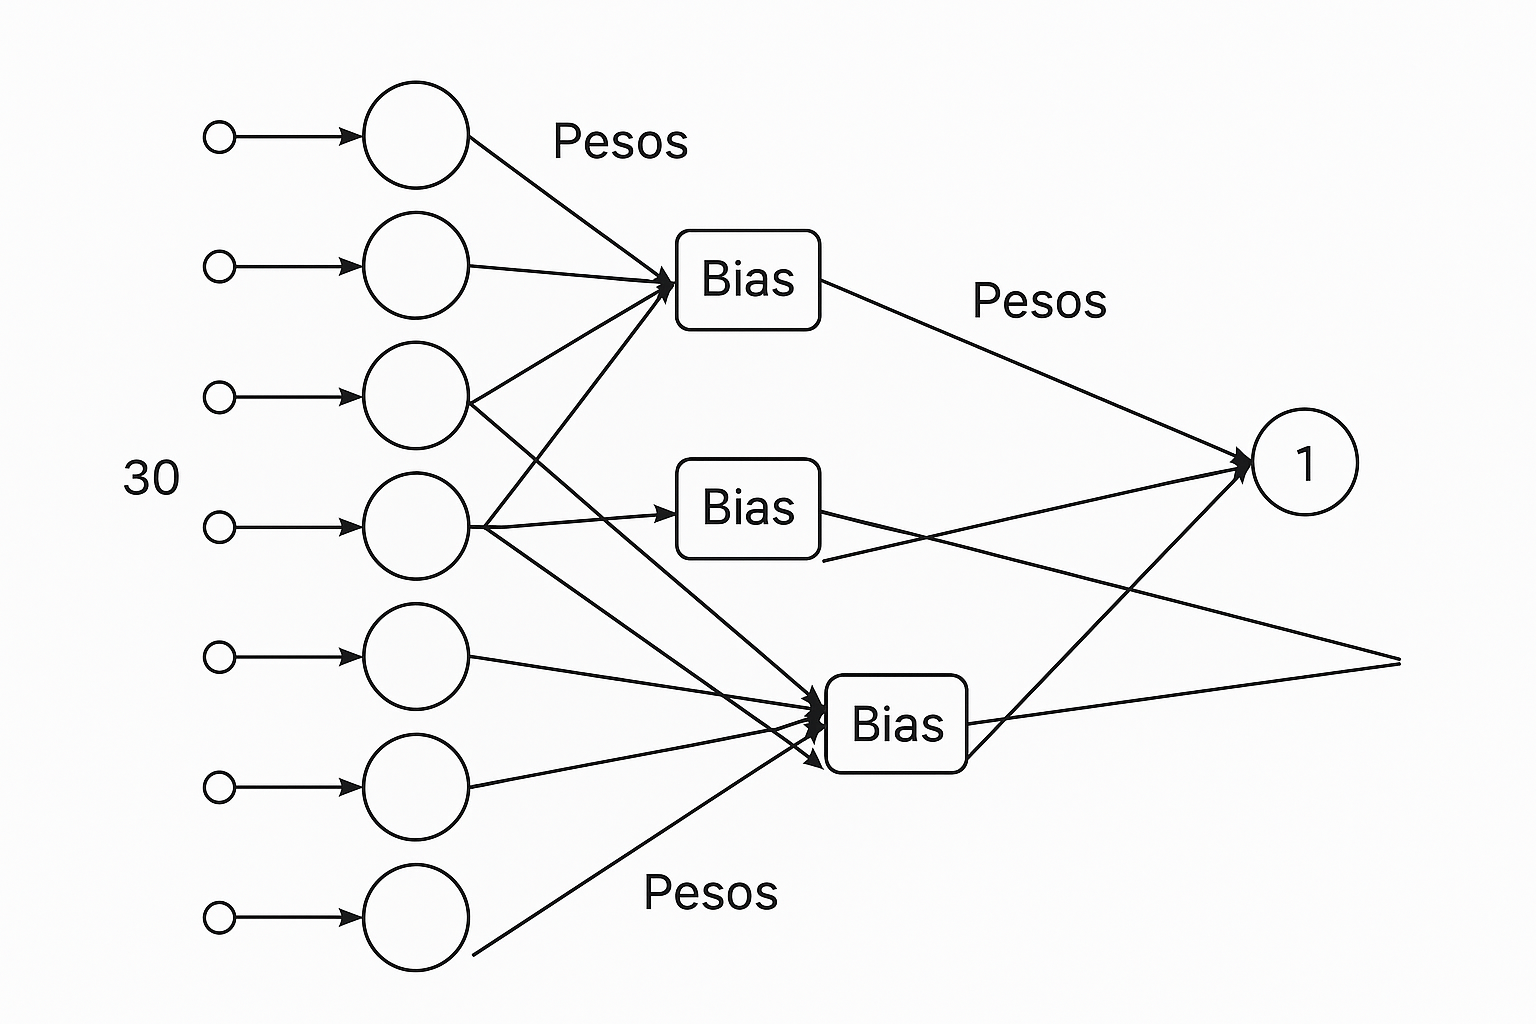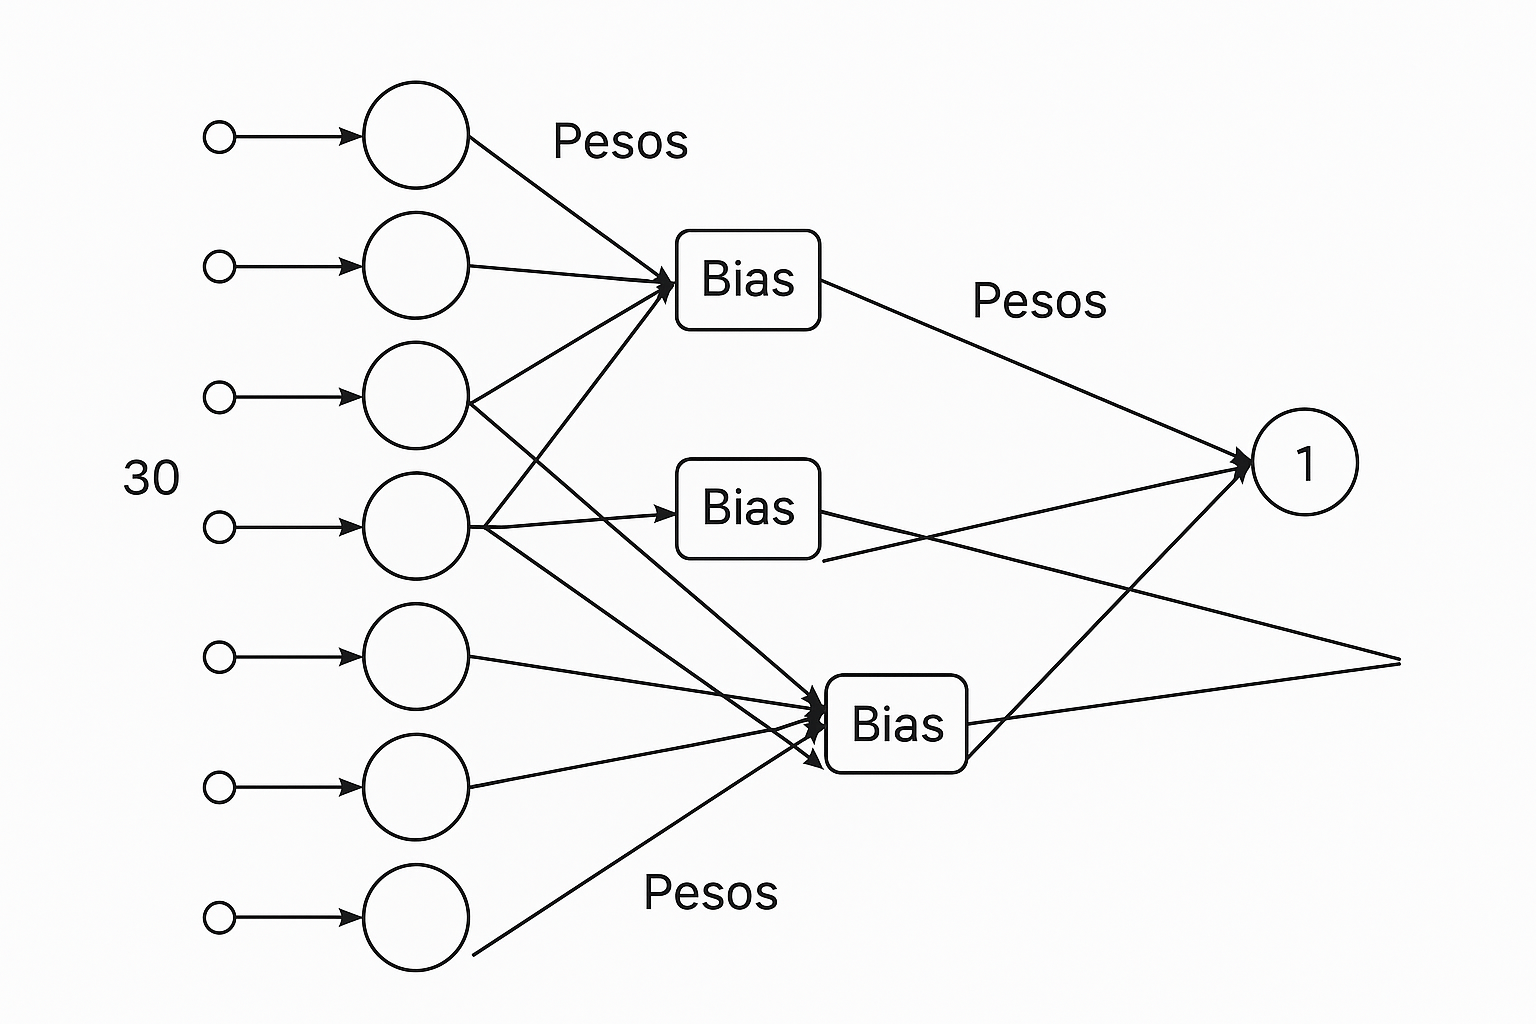

saída = f((x1⋅w1)+(x2⋅w2)+...+(xn⋅wn)+b)

onde 
f é a função de ativação, 

w são os pesos, 

b é o bias.

## Etapa 7: Avaliação do modelo

avaliação do modelo com base nos dados de .


evaluate: eval()

classificador em modo de avaliação

# com o eval para de fazer os cálculos dos pesos

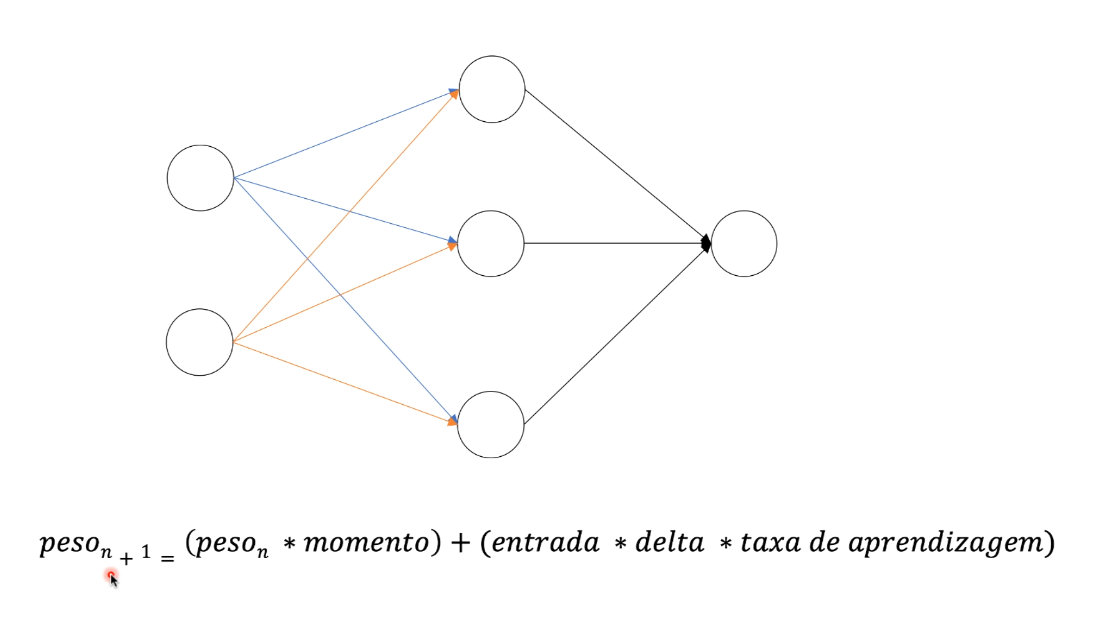

como a classificação neste é exemplo é em modo de avaliação ele não calcula o peso_n*momento., ou seja, não atualiza os pesos.

In [69]:
classificador.eval()
# função eval desliga os cálculos dos pesos

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

In [70]:
type(previsores_teste) # modo do dataframe
# mudar para numpy e depois para o pytorch

pandas.core.frame.DataFrame

In [71]:
# não vamos passar a classe, pois neste caso faremos as previsões das classes para depois comparar com os dados reais
# para isso serve os dados do teste
previsores_teste = torch.tensor(np.array(previsores_teste), dtype=torch.float)

In [73]:
type(previsores_teste) # formato do pytorch

torch.Tensor

In [75]:
previsoes = classificador.forward(previsores_teste) # forward fará a previsão e vai passar pela rede neural.
# atributos de previsão=> previsores_teste, para achar as classes

In [78]:
# retornar a probabilidade para as classes 0 ou 1, para cada um dos registros;
previsoes

tensor([[9.6916e-01],
        [1.0000e+00],
        [1.3340e-02],
        [9.0706e-01],
        [1.7867e-05],
        [5.4273e-01],
        [8.9940e-01],
        [9.9613e-01],
        [4.6947e-01],
        [1.8971e-01],
        [8.6614e-01],
        [7.5343e-01],
        [4.3482e-01],
        [9.7639e-01],
        [1.9593e-01],
        [6.6657e-01],
        [9.6952e-01],
        [1.0000e+00],
        [1.2658e-01],
        [9.9693e-01],
        [1.7531e-13],
        [3.4261e-03],
        [3.9201e-01],
        [1.0000e+00],
        [6.0287e-01],
        [1.5253e-04],
        [2.9383e-01],
        [1.0000e+00],
        [2.7241e-06],
        [9.9177e-01],
        [7.9016e-02],
        [9.9983e-01],
        [7.6457e-01],
        [8.7721e-01],
        [3.4287e-02],
        [9.8662e-01],
        [3.3647e-02],
        [9.9760e-01],
        [9.7739e-01],
        [2.5657e-06],
        [6.8363e-04],
        [8.0589e-01],
        [1.7228e-09],
        [2.7349e-01],
        [3.2712e-06],
        [3

In [77]:
len(previsoes)

143

Valores de 0 e 1: previsoes

- valores maiores que 0,5 são considerados da classe 1 => como a probabilidade de ter um câncer.

- e iguais ou menor que 0,5 são classificados como da classe 0

In [79]:
# padrão para teste
previsoes = np.array(previsoes > 0.5)
previsoes

array([[ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

sistema já auto classifica.

True classe 1

False classe 0

- Verificar a taxa de acerto:



In [80]:
classe_teste # dados reais

,0
333,1
273,1
201,0
178,1
85,0
...,...
230,0
282,0
535,0
436,1


In [81]:
# calcular a acurácia, valores do teste e a previsão

taxa_acerto = accuracy_score(classe_teste, previsoes)

taxa_acerto

0.9090909090909091

In [85]:
print(f'taxa de acerto é de {taxa_acerto*100:.2f} % do modelo') # resultado bom

taxa de acerto é de 90.91 % do modelo


In [86]:
matriz = confusion_matrix(classe_teste, previsoes)
matriz

array([[50,  4],
       [ 9, 80]])

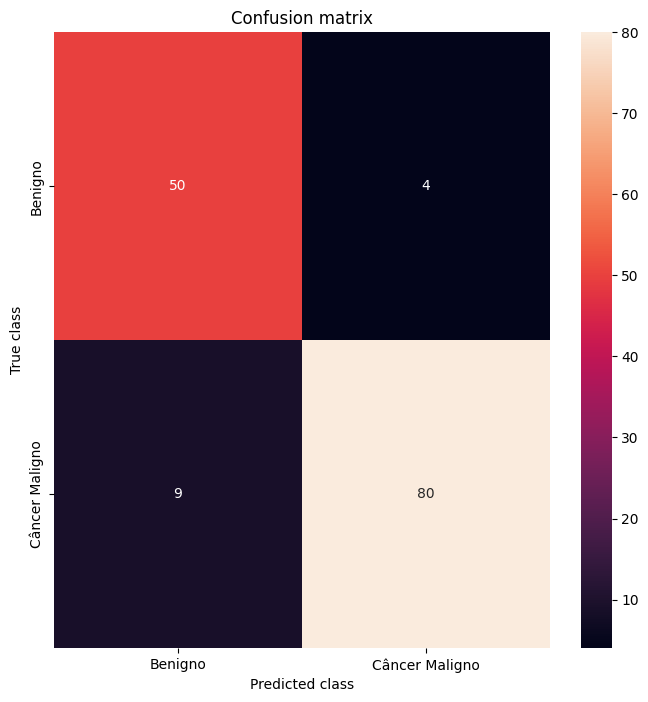

In [87]:
LABELS = ["Benigno", "Câncer Maligno"]

plt.figure(figsize=(8, 8))
sns.heatmap(matriz, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [89]:

print('True negatives - actually non-cancer and correctly classified as non-cancer')
print(matriz[0][0]) #normal 
print('False positives - actually non-cancer but incorrectly classified as cancer')
print(matriz[0][1]) # normal but predicted cancer 
print('False negatives - actually cancer but incorrectly classified as being non-cancer')
print(matriz[1][0]) # cancer but predicted normal 
print('True positives - actually cancer and correctly classified as cancer')
print(matriz[1][1]) # cancer 

True negatives - actually non-cancer and correctly classified as non-cancer
50
False positives - actually non-cancer but incorrectly classified as cancer
4
False negatives - actually cancer but incorrectly classified as being non-cancer
9
True positives - actually cancer and correctly classified as cancer
80


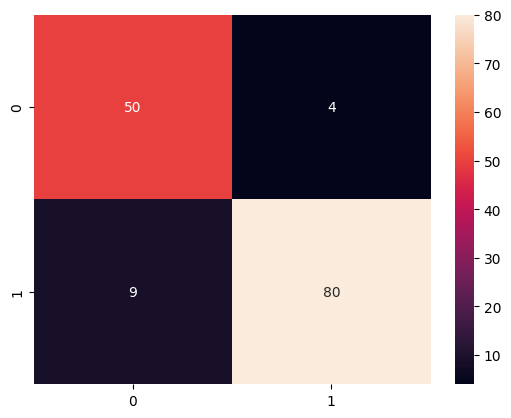

In [90]:
# tirar a mensagem do matplotlib => ;
sns.heatmap(matriz, annot=True);

In [91]:
# estudo com a classificaçção binária com a base de dados breast cancer 